# Get Restaurant Info from New York Open Data

In [2]:
import requests
import pandas as pd
import time

BASE_URL = "https://data.cityofnewyork.us/resource/9w7m-hzhe.json"

LIMIT = 50000
OFFSET = 0

all_rows = []

while True:
    params = {
        "$limit": LIMIT,
        "$offset": OFFSET,
        "$select": (
            "camis, dba, boro, building, street, zipcode, "
            "cuisine_description, grade, score, inspection_date, "
            "latitude, longitude"
        ),
        "$where": (
            "boro='Manhattan' "
            "AND latitude IS NOT NULL "
            "AND longitude IS NOT NULL"
        )
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code != 200:
        print("Error:", response.status_code)
        print(response.text)
        break

    rows = response.json()

    if not rows:
        break

    all_rows.extend(rows)
    print(f"Fetched {len(all_rows)} rows...")

    OFFSET += LIMIT
    time.sleep(0.2)

df = pd.DataFrame(all_rows)

# Convert numeric fields
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["inspection_date"] = pd.to_datetime(df["inspection_date"], errors="coerce")

# Keep latest inspection record per restaurant
df = df.sort_values("inspection_date", ascending=False)

df_unique = df.drop_duplicates(subset=["camis"], keep="first").copy()

# Rename columns
df_unique = df_unique.rename(columns={
    "camis": "restaurant_id",
    "dba": "name",
    "boro": "borough",
    "cuisine_description": "cuisine",
    "grade": "inspection_grade",
    "score": "inspection_score"
})

# Create full address
df_unique["address"] = (
    df_unique["building"].fillna("") + " " +
    df_unique["street"].fillna("") + ", " +
    df_unique["borough"].fillna("") + ", NY " +
    df_unique["zipcode"].fillna("")
)

# Select useful fields
df_final = df_unique[[
    "restaurant_id",
    "name",
    "borough",
    "address",
    "zipcode",
    "cuisine",
    "inspection_grade",
    "inspection_score",
    "inspection_date",
    "latitude",
    "longitude"
]]

df_final.to_csv("manhattan_restaurants.csv", index=False, encoding="utf-8-sig")

print("Finished.")
print(f"Unique Manhattan restaurants: {len(df_final)}")
print("Saved as manhattan_restaurants.csv")
print(df_final.head())

Fetched 50000 rows...
Fetched 100000 rows...
Fetched 109217 rows...
Finished.
Unique Manhattan restaurants: 12369
Saved as manhattan_restaurants.csv
       restaurant_id               name    borough  \
50321       50111559    DOUGH DOUGHNUTS  Manhattan   
106076      50152959           GONG CHA  Manhattan   
22947       41562415  THE COMFORT DINER  Manhattan   
23161       50181856     SUNDAY MORNING  Manhattan   
106478      50117809          MING WONG  Manhattan   

                                          address zipcode  \
50321     10 ROCKEFELLER PLZ, Manhattan, NY 10020   10020   
106076        42 MOTT STREET, Manhattan, NY 10013   10013   
22947   214 EAST   45 STREET, Manhattan, NY 10017   10017   
23161    11 WEST   25 STREET, Manhattan, NY 10010   10010   
106478        61 MOTT STREET, Manhattan, NY 10013   10013   

                         cuisine inspection_grade  inspection_score  \
50321                     Donuts                Z              42.0   
106076           

# Get Pedestrain Data from New York Open Data

In [4]:
import requests
import pandas as pd

# =========================
# 1. Pedestrian Counts
# =========================

PED_URL = "https://data.cityofnewyork.us/resource/cqsj-cfgu.json"

params = {
    "$limit": 50000,
    "$where": "the_geom IS NOT NULL"
}

ped_response = requests.get(PED_URL, params=params)
print("Pedestrian status:", ped_response.status_code)

ped_data = ped_response.json()
ped_df = pd.DataFrame(ped_data)

print("Pedestrian columns:")
print(ped_df.columns)

ped_df.to_csv("manhattan_pedestrian_counts_raw.csv", index=False, encoding="utf-8-sig")

print("Saved: manhattan_pedestrian_counts_raw.csv")
print("Rows:", len(ped_df))

Pedestrian status: 200
Pedestrian columns:
Index(['the_geom', 'objectid', 'loc', 'borough', 'street_nam', 'from_stree',
       'to_street', 'iex', 'may_07_am', 'may_07_pm',
       ...
       'oct24_md', 'may25_am', 'may25_pm', 'may25_md', 'oct25_am', 'oct25_pm',
       'oct25_md', 'may_19_am', 'may_19_pm', 'may_19_md'],
      dtype='object', length=116)
Saved: manhattan_pedestrian_counts_raw.csv
Rows: 114


# Get Taxi Data from New York Open Data

In [6]:
import pandas as pd

# =========================
# 1. Download Taxi Zone Lookup
# =========================

lookup_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

zone_lookup = pd.read_csv(lookup_url)

manhattan_zones = zone_lookup[
    zone_lookup["Borough"] == "Manhattan"
]["LocationID"].tolist()

print(f"Manhattan taxi zones: {len(manhattan_zones)}")


# =========================
# 2. Aggregate Yellow Taxi Dropoffs by Month
# =========================

all_monthly_results = []

YEAR = 2025

for month in range(1, 13):
    taxi_url = (
        f"https://d37ci6vzurychx.cloudfront.net/trip-data/"
        f"yellow_tripdata_{YEAR}-{month:02d}.parquet"
    )

    print(f"\nLoading: {taxi_url}")

    try:
        taxi_df = pd.read_parquet(
            taxi_url,
            columns=[
                "tpep_dropoff_datetime",
                "DOLocationID",
                "passenger_count",
                "trip_distance"
            ]
        )
    except Exception as e:
        print(f"Failed to load month {month}: {e}")
        continue

    print(f"Rows before filtering: {len(taxi_df):,}")

    # Convert datetime
    taxi_df["tpep_dropoff_datetime"] = pd.to_datetime(
        taxi_df["tpep_dropoff_datetime"],
        errors="coerce"
    )

    # Remove invalid rows
    taxi_df = taxi_df.dropna(subset=["tpep_dropoff_datetime", "DOLocationID"])

    # Keep only Manhattan dropoff zones
    taxi_df = taxi_df[
        taxi_df["DOLocationID"].isin(manhattan_zones)
    ].copy()

    print(f"Rows after Manhattan filtering: {len(taxi_df):,}")

    if taxi_df.empty:
        continue

    # Create time features
    taxi_df["month"] = taxi_df["tpep_dropoff_datetime"].dt.month
    taxi_df["weekday"] = taxi_df["tpep_dropoff_datetime"].dt.dayofweek
    taxi_df["hour"] = taxi_df["tpep_dropoff_datetime"].dt.hour

    # Optional cleaning
    taxi_df = taxi_df[
        (taxi_df["trip_distance"] >= 0) &
        (taxi_df["passenger_count"].fillna(1) >= 0)
    ]

    # Aggregate
    monthly_agg = (
        taxi_df
        .groupby(
            [
                "DOLocationID",
                "month",
                "weekday",
                "hour"
            ]
        )
        .agg(
            dropoff_count=("DOLocationID", "size"),
            passenger_count_sum=("passenger_count", "sum"),
            avg_trip_distance=("trip_distance", "mean")
        )
        .reset_index()
    )

    all_monthly_results.append(monthly_agg)

    print(f"Aggregated rows: {len(monthly_agg):,}")


# =========================
# 3. Combine All Months
# =========================

if not all_monthly_results:
    raise ValueError("No taxi data was collected. Please check URLs or network connection.")

demand_df = pd.concat(all_monthly_results, ignore_index=True)


# =========================
# 4. Add Taxi Zone Name
# =========================

demand_df = demand_df.merge(
    zone_lookup[["LocationID", "Borough", "Zone", "service_zone"]],
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

demand_df = demand_df.rename(columns={
    "DOLocationID": "taxi_zone_id",
    "Zone": "taxi_zone_name",
    "Borough": "borough"
})

demand_df = demand_df[
    [
        "taxi_zone_id",
        "taxi_zone_name",
        "borough",
        "service_zone",
        "month",
        "weekday",
        "hour",
        "dropoff_count",
        "passenger_count_sum",
        "avg_trip_distance"
    ]
]


# =========================
# 5. Export
# =========================

output_file = "manhattan_hourly_demand.csv"

demand_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\nFinished.")
print(f"Saved as: {output_file}")
print(f"Total aggregated rows: {len(demand_df):,}")
print(demand_df.head())

Manhattan taxi zones: 69

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet
Rows before filtering: 3,475,226
Rows after Manhattan filtering: 3,116,979
Aggregated rows: 10,886

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-02.parquet
Rows before filtering: 3,577,543
Rows after Manhattan filtering: 3,190,416
Aggregated rows: 10,918

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-03.parquet
Rows before filtering: 4,145,257
Rows after Manhattan filtering: 3,620,516
Aggregated rows: 10,988

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-04.parquet
Rows before filtering: 3,970,553
Rows after Manhattan filtering: 3,476,187
Aggregated rows: 10,986

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-05.parquet
Rows before filtering: 4,591,845
Rows after Manhattan filtering: 3,952,013
Aggregated rows: 11,056

Loading: https://d37ci6vzuryc

# Data Cleaning for Restauraunt

In [8]:
import pandas as pd
import numpy as np

# =========================
# 1. Load raw restaurant data
# =========================

input_file = "manhattan_restaurants.csv"
output_file = "restaurant_clean.csv"

df = pd.read_csv(input_file)

print("Raw shape:", df.shape)
print("Raw columns:", df.columns.tolist())


# =========================
# 2. Standardize column names
# =========================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Standardized columns:", df.columns.tolist())


# =========================
# 3. Convert numeric columns
# =========================

numeric_cols = ["latitude", "longitude", "inspection_score"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# =========================
# 4. Convert date columns
# =========================

if "inspection_date" in df.columns:
    df["inspection_date"] = pd.to_datetime(
        df["inspection_date"],
        errors="coerce"
    )


# =========================
# 5. Drop rows with missing key fields
# =========================

required_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "latitude",
    "longitude"
]

missing_required = [
    col for col in required_cols
    if col not in df.columns
]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df.dropna(subset=required_cols)

print("After dropping missing key fields:", df.shape)


# =========================
# 6. Clean text fields
# =========================

df["restaurant_id"] = df["restaurant_id"].astype(str).str.strip()

df["name"] = (
    df["name"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["cuisine"] = (
    df["cuisine"]
    .astype(str)
    .str.strip()
    .str.title()
)

if "address" in df.columns:
    df["address"] = (
        df["address"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
else:
    df["address"] = np.nan

if "zipcode" in df.columns:
    df["zipcode"] = (
        df["zipcode"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
    )
else:
    df["zipcode"] = np.nan


# =========================
# 7. Remove invalid restaurant names
# =========================

bad_names = [
    "",
    "NAN",
    "UNKNOWN",
    "NOT LISTED",
    "TEST",
    "N/A",
    "NA",
    "NONE"
]

df = df[~df["name"].isin(bad_names)]

print("After removing bad names:", df.shape)


# =========================
# 8. Filter Manhattan coordinate range
# =========================

df = df[
    (df["latitude"] >= 40.7000) &
    (df["latitude"] <= 40.8800) &
    (df["longitude"] >= -74.0300) &
    (df["longitude"] <= -73.9000)
].copy()

print("After Manhattan coordinate filtering:", df.shape)


# =========================
# 9. Keep latest inspection if duplicates exist
# =========================

if "inspection_date" in df.columns:
    df = df.sort_values("inspection_date", ascending=False)

df = df.drop_duplicates(
    subset=["restaurant_id"],
    keep="first"
).copy()

print("After restaurant_id deduplication:", df.shape)


# =========================
# 10. Optional: remove duplicate same name + same address
# =========================

if "address" in df.columns:
    df = df.drop_duplicates(
        subset=["name", "address"],
        keep="first"
    ).copy()

print("After name + address deduplication:", df.shape)


# =========================
# 11. Standardize inspection fields
# =========================

if "inspection_grade" not in df.columns:
    df["inspection_grade"] = np.nan

if "inspection_score" not in df.columns:
    df["inspection_score"] = np.nan

df["inspection_grade"] = (
    df["inspection_grade"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"NAN": np.nan})
)


# =========================
# 12. Keep useful columns
# =========================

final_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "address",
    "zipcode",
    "inspection_grade",
    "inspection_score",
    "inspection_date",
    "latitude",
    "longitude"
]

for col in final_cols:
    if col not in df.columns:
        df[col] = np.nan

restaurant_clean = df[final_cols].copy()

restaurant_clean = restaurant_clean.rename(columns={
    "latitude": "lat",
    "longitude": "lon"
})


# =========================
# 13. Export
# =========================

restaurant_clean.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("\nFinished.")
print(f"Saved as: {output_file}")
print("Clean shape:", restaurant_clean.shape)
print("Unique restaurants:", restaurant_clean["restaurant_id"].nunique())
print("Unique cuisines:", restaurant_clean["cuisine"].nunique())

print("\nTop 20 cuisines:")
print(restaurant_clean["cuisine"].value_counts().head(20))

print("\nPreview:")
print(restaurant_clean.head())

Raw shape: (12369, 11)
Raw columns: ['restaurant_id', 'name', 'borough', 'address', 'zipcode', 'cuisine', 'inspection_grade', 'inspection_score', 'inspection_date', 'latitude', 'longitude']
Standardized columns: ['restaurant_id', 'name', 'borough', 'address', 'zipcode', 'cuisine', 'inspection_grade', 'inspection_score', 'inspection_date', 'latitude', 'longitude']
After dropping missing key fields: (10793, 11)
After removing bad names: (10793, 11)
After Manhattan coordinate filtering: (10610, 11)
After restaurant_id deduplication: (10610, 11)
After name + address deduplication: (10545, 11)

Finished.
Saved as: restaurant_clean.csv
Clean shape: (10545, 10)
Unique restaurants: 10545
Unique cuisines: 88

Top 20 cuisines:
cuisine
American                          2380
Coffee/Tea                        1102
Italian                            596
Japanese                           553
Chinese                            529
Pizza                              475
Bakery Products/Desserts       

In [9]:
restaurant_clean["cuisine"].value_counts().head(31)

cuisine
American                          2380
Coffee/Tea                        1102
Italian                            596
Japanese                           553
Chinese                            529
Pizza                              475
Bakery Products/Desserts           307
Mexican                            293
Other                              234
French                             231
Juice, Smoothies, Fruit Salads     203
Latin American                     199
Sandwiches                         196
Asian/Asian Fusion                 192
Korean                             177
Mediterranean                      171
Donuts                             163
Indian                             148
Chicken                            147
Thai                               146
Frozen Desserts                    142
Hamburgers                         140
Spanish                            116
Tex-Mex                            116
New American                       114
Irish            

In [10]:
restaurant_clean.shape

(10545, 10)

In [11]:
restaurant_clean["address"].head()

0       10 ROCKEFELLER PLZ, MANHATTAN, NY 10020
26    355 AMSTERDAM AVENUE, MANHATTAN, NY 10024
20           344 E 34TH ST, MANHATTAN, NY 10016
21    204 EAST   60 STREET, MANHATTAN, NY 10022
22    343 AMSTERDAM AVENUE, MANHATTAN, NY 10024
Name: address, dtype: object

# Get the Building Area

In [13]:
import requests
import pandas as pd
import time

# NYC Open Data PLUTO Socrata endpoint
BASE_URL = "https://data.cityofnewyork.us/resource/64uk-42ks.json"

OUTPUT_FILE = "manhattan_pluto.csv"

LIMIT = 50000
OFFSET = 0

all_rows = []

# Manhattan borough code in PLUTO is usually MN
where_clause = (
    "borough = 'MN' "
    "AND latitude IS NOT NULL "
    "AND longitude IS NOT NULL"
)

select_cols = (
    "borough, block, lot, bbl, address, zipcode, "
    "latitude, longitude, "
    "landuse, lotarea, bldgarea, comarea, retailarea, officearea, "
    "resarea, numfloors, unitsres, unitstotal, yearbuilt"
)

while True:
    params = {
        "$limit": LIMIT,
        "$offset": OFFSET,
        "$select": select_cols,
        "$where": where_clause
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code != 200:
        print("Error:", response.status_code)
        print(response.text)
        break

    rows = response.json()

    if not rows:
        break

    all_rows.extend(rows)
    print(f"Fetched {len(all_rows):,} PLUTO rows...")

    OFFSET += LIMIT
    time.sleep(0.2)

pluto = pd.DataFrame(all_rows)

print("Raw PLUTO shape:", pluto.shape)
print("Columns:", pluto.columns.tolist())

# Convert numeric columns
numeric_cols = [
    "block", "lot", "bbl", "zipcode",
    "latitude", "longitude",
    "landuse", "lotarea", "bldgarea", "comarea", "retailarea",
    "officearea", "resarea", "numfloors", "unitsres",
    "unitstotal", "yearbuilt"
]

for col in numeric_cols:
    if col in pluto.columns:
        pluto[col] = pd.to_numeric(pluto[col], errors="coerce")

# Clean address
if "address" in pluto.columns:
    pluto["address"] = (
        pluto["address"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

# Keep Manhattan coordinate range
pluto = pluto[
    (pluto["latitude"] >= 40.7000) &
    (pluto["latitude"] <= 40.8800) &
    (pluto["longitude"] >= -74.0300) &
    (pluto["longitude"] <= -73.9000)
].copy()

# Remove invalid area records
pluto = pluto[
    (pluto["bldgarea"].fillna(0) >= 0) &
    (pluto["lotarea"].fillna(0) >= 0)
].copy()

# Useful derived fields
pluto["commercial_area_proxy"] = pluto[["comarea", "retailarea"]].max(axis=1)

pluto["has_commercial_space"] = (
    pluto["commercial_area_proxy"].fillna(0) > 0
).astype(int)

pluto.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

print("\nFinished.")
print(f"Saved as: {OUTPUT_FILE}")
print("Clean PLUTO shape:", pluto.shape)

print("\nArea summary:")
print(
    pluto[
        ["lotarea", "bldgarea", "comarea", "retailarea", "commercial_area_proxy"]
    ].describe()
)

print("\nPreview:")
print(pluto.head())

Fetched 42,102 PLUTO rows...
Raw PLUTO shape: (42102, 19)
Columns: ['borough', 'block', 'lot', 'bbl', 'address', 'zipcode', 'latitude', 'longitude', 'landuse', 'lotarea', 'bldgarea', 'comarea', 'retailarea', 'officearea', 'resarea', 'numfloors', 'unitsres', 'unitstotal', 'yearbuilt']

Finished.
Saved as: manhattan_pluto.csv
Clean PLUTO shape: (42095, 21)

Area summary:
            lotarea      bldgarea       comarea    retailarea  \
count  4.206000e+04  4.205700e+04  3.967100e+04  3.967100e+04   
mean   1.175103e+04  4.327915e+04  2.032794e+04  2.695625e+03   
std    2.371677e+05  1.642616e+05  1.405561e+05  2.173873e+04   
min    1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    1.939000e+03  4.525000e+03  0.000000e+00  0.000000e+00   
50%    2.523000e+03  9.135000e+03  1.000000e+03  0.000000e+00   
75%    6.025000e+03  2.460000e+04  4.342500e+03  1.900000e+03   
max    3.659000e+07  1.343508e+07  1.343508e+07  2.192088e+06   

       commercial_area_proxy  
count      

# Get Restauraunt Area

In [15]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# =========================
# 1. Load data
# =========================

restaurant_file = "restaurant_clean.csv"
pluto_file = "manhattan_pluto.csv"
output_file = "restaurant_area.csv"

restaurants = pd.read_csv(restaurant_file)
pluto = pd.read_csv(pluto_file)

print("Restaurants:", restaurants.shape)
print("PLUTO:", pluto.shape)


# =========================
# 2. Standardize column names
# =========================

restaurants.columns = (
    restaurants.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

pluto.columns = (
    pluto.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


# =========================
# 3. Convert numeric fields
# =========================

for col in ["lat", "lon"]:
    restaurants[col] = pd.to_numeric(restaurants[col], errors="coerce")

pluto_numeric_cols = [
    "bbl", "latitude", "longitude",
    "lotarea", "bldgarea", "comarea", "retailarea",
    "officearea", "resarea", "numfloors", "unitstotal"
]

for col in pluto_numeric_cols:
    if col in pluto.columns:
        pluto[col] = pd.to_numeric(pluto[col], errors="coerce")


# =========================
# 4. Basic cleaning
# =========================

restaurants = restaurants.dropna(
    subset=["restaurant_id", "name", "cuisine", "lat", "lon"]
).copy()

pluto = pluto.dropna(
    subset=["bbl", "latitude", "longitude"]
).copy()

# Manhattan coordinate range
restaurants = restaurants[
    (restaurants["lat"] >= 40.7000) &
    (restaurants["lat"] <= 40.8800) &
    (restaurants["lon"] >= -74.0300) &
    (restaurants["lon"] <= -73.9000)
].copy()

pluto = pluto[
    (pluto["latitude"] >= 40.7000) &
    (pluto["latitude"] <= 40.8800) &
    (pluto["longitude"] >= -74.0300) &
    (pluto["longitude"] <= -73.9000)
].copy()

print("Restaurants after cleaning:", restaurants.shape)
print("PLUTO after cleaning:", pluto.shape)


# =========================
# 5. Create commercial area proxy
# =========================

# Ensure required area columns exist
for col in ["comarea", "retailarea", "bldgarea"]:
    if col not in pluto.columns:
        pluto[col] = np.nan

pluto["comarea"] = pluto["comarea"].fillna(0)
pluto["retailarea"] = pluto["retailarea"].fillna(0)
pluto["bldgarea"] = pluto["bldgarea"].fillna(0)

# Main proxy: max(comarea, retailarea)
pluto["commercial_area_proxy"] = pluto[["comarea", "retailarea"]].max(axis=1)

# If commercial area is missing/zero, fallback to 30% of building area
pluto["commercial_area_proxy"] = np.where(
    pluto["commercial_area_proxy"] > 0,
    pluto["commercial_area_proxy"],
    pluto["bldgarea"] * 0.30
)

# Final fallback: 0 if still missing
pluto["commercial_area_proxy"] = (
    pluto["commercial_area_proxy"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Remove lots with no usable area
pluto = pluto[pluto["commercial_area_proxy"] > 0].copy()

print("PLUTO with usable commercial area:", pluto.shape)


# =========================
# 6. Nearest-neighbor spatial match
# =========================

# BallTree uses radians
restaurant_coords = np.radians(
    restaurants[["lat", "lon"]].to_numpy()
)

pluto_coords = np.radians(
    pluto[["latitude", "longitude"]].to_numpy()
)

tree = BallTree(pluto_coords, metric="haversine")

distances, indices = tree.query(
    restaurant_coords,
    k=1
)

# Convert radians to meters
earth_radius_m = 6371000
restaurants["match_distance_m"] = distances[:, 0] * earth_radius_m

matched_pluto = pluto.iloc[indices[:, 0]].reset_index(drop=True)
restaurants = restaurants.reset_index(drop=True)

restaurant_pluto = pd.concat(
    [
        restaurants,
        matched_pluto.add_prefix("pluto_")
    ],
    axis=1
)

print("Matched restaurant_pluto:", restaurant_pluto.shape)


# =========================
# 7. Optional: flag suspicious matches
# =========================

# In dense Manhattan, nearest lot should usually be very close.
# Keep all rows, but flag anything over 100 meters.
restaurant_pluto["match_quality"] = np.where(
    restaurant_pluto["match_distance_m"] <= 50,
    "good",
    np.where(
        restaurant_pluto["match_distance_m"] <= 100,
        "acceptable",
        "check"
    )
)

print("\nMatch quality:")
print(restaurant_pluto["match_quality"].value_counts())


# =========================
# 8. Count restaurants per matched building / BBL
# =========================

bbl_counts = (
    restaurant_pluto
    .groupby("pluto_bbl")
    .size()
    .reset_index(name="restaurant_count_in_bbl")
)

restaurant_pluto = restaurant_pluto.merge(
    bbl_counts,
    on="pluto_bbl",
    how="left"
)


# =========================
# 9. Estimate restaurant area
# =========================

def food_service_share(commercial_area):
    if commercial_area <= 3000:
        return 0.80
    elif commercial_area <= 10000:
        return 0.50
    elif commercial_area <= 50000:
        return 0.30
    elif commercial_area <= 100000:
        return 0.15
    else:
        return 0.05


restaurant_pluto["food_service_share"] = (
    restaurant_pluto["pluto_commercial_area_proxy"]
    .apply(food_service_share)
)

restaurant_pluto["raw_estimated_area_sqft"] = (
    restaurant_pluto["pluto_commercial_area_proxy"]
    * restaurant_pluto["food_service_share"]
    / restaurant_pluto["restaurant_count_in_bbl"]
)

# Apply reasonable lower and upper bounds
restaurant_pluto["estimated_area_sqft"] = (
    restaurant_pluto["raw_estimated_area_sqft"]
    .clip(lower=200, upper=8000)
)

# =========================
# 10. Keep useful output columns
# =========================

keep_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "address",
    "zipcode",
    "inspection_grade",
    "inspection_score",
    "lat",
    "lon",
    "pluto_bbl",
    "pluto_address",
    "pluto_zipcode",
    "pluto_landuse",
    "pluto_lotarea",
    "pluto_bldgarea",
    "pluto_comarea",
    "pluto_retailarea",
    "pluto_commercial_area_proxy",
    "restaurant_count_in_bbl",
    "raw_estimated_area_sqft",
    "estimated_area_sqft",
    "match_distance_m",
    "match_quality"
]

for col in keep_cols:
    if col not in restaurant_pluto.columns:
        restaurant_pluto[col] = np.nan

restaurant_area = restaurant_pluto[keep_cols].copy()


# =========================
# 11. Export
# =========================

restaurant_area.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("\nFinished.")
print(f"Saved as: {output_file}")
print("Output shape:", restaurant_area.shape)

print("\nArea summary:")
print(
    restaurant_area[
        [
            "raw_estimated_area_sqft",
            "estimated_area_sqft",
            "match_distance_m"
        ]
    ].describe()
)

print("\nPreview:")
print(restaurant_area.head())

Restaurants: (10545, 10)
PLUTO: (42095, 21)
Restaurants after cleaning: (10545, 10)
PLUTO after cleaning: (42095, 21)
PLUTO with usable commercial area: (40102, 21)
Matched restaurant_pluto: (10545, 32)

Match quality:
match_quality
good          9965
acceptable     564
check           16
Name: count, dtype: int64

Finished.
Saved as: restaurant_area.csv
Output shape: (10545, 23)

Area summary:
       raw_estimated_area_sqft  estimated_area_sqft  match_distance_m
count             10545.000000         10545.000000      10545.000000
mean               2562.280738          2110.912624         28.598782
std                4669.393066          2173.688301         13.530651
min                   0.800000           200.000000          1.056777
25%                 648.000000           648.000000         22.163625
50%                1210.307143          1210.307143         25.677502
75%                2537.500000          2537.500000         31.286887
max              117714.450000          80

# Cuisine Profile Assumption and Supply-side Estimation

In [17]:
import numpy as np
import pandas as pd
# =========================
# 1. Create cuisine_profile
# =========================

profile_data = [
    ["American", 0.060, 1.2, 0.20],
    ["Coffee/Tea", 0.083, 3.0, 0.70],
    ["Italian", 0.055, 1.0, 0.10],
    ["Japanese", 0.055, 1.0, 0.15],
    ["Chinese", 0.060, 1.2, 0.30],
    ["Pizza", 0.067, 1.8, 0.50],
    ["Bakery Products/Desserts", 0.083, 3.0, 0.70],
    ["Mexican", 0.067, 1.8, 0.40],
    ["Other", 0.060, 1.1, 0.20],
    ["French", 0.050, 0.8, 0.05],
    ["Juice, Smoothies, Fruit Salads", 0.083, 3.0, 0.80],
    ["Latin American", 0.060, 1.2, 0.20],
    ["Sandwiches", 0.083, 2.5, 0.60],
    ["Asian/Asian Fusion", 0.060, 1.1, 0.20],
    ["Korean", 0.055, 1.0, 0.15],
    ["Mediterranean", 0.060, 1.2, 0.20],
    ["Donuts", 0.083, 3.0, 0.80],
    ["Indian", 0.055, 1.0, 0.15],
    ["Chicken", 0.067, 2.0, 0.50],
    ["Thai", 0.055, 1.0, 0.15],
    ["Frozen Desserts", 0.083, 3.0, 0.80],
    ["Hamburgers", 0.083, 2.5, 0.60],
    ["Spanish", 0.055, 0.9, 0.10],
    ["Tex-Mex", 0.067, 1.8, 0.40],
    ["New American", 0.050, 0.8, 0.05],
    ["Irish", 0.055, 1.0, 0.10],
    ["Bagels/Pretzels", 0.083, 3.0, 0.80],
    ["Salads", 0.083, 2.5, 0.60],
    ["Seafood", 0.050, 0.8, 0.05],
    ["Jewish/Kosher", 0.060, 1.1, 0.15],
    ["Sandwiches/Salads/Mixed Buffet", 0.083, 2.5, 0.60],
]

cuisine_profile = pd.DataFrame(
    profile_data,
    columns=[
        "cuisine",
        "seat_density",
        "turnover_rate",
        "takeaway_ratio"
    ]
)

cuisine_profile.to_csv(
    "cuisine_profile.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved cuisine_profile.csv")
print(cuisine_profile.head())


# =========================
# 2. Load restaurant_area
# =========================

restaurant_area = pd.read_csv("restaurant_area.csv")

restaurant_area.columns = (
    restaurant_area.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

restaurant_area["cuisine"] = (
    restaurant_area["cuisine"]
    .astype(str)
    .str.strip()
)

restaurant_area["estimated_area_sqft"] = pd.to_numeric(
    restaurant_area["estimated_area_sqft"],
    errors="coerce"
)

print("Restaurant area shape:", restaurant_area.shape)


# =========================
# 3. Keep only cuisines in profile
# =========================

restaurant_supply = restaurant_area.merge(
    cuisine_profile,
    on="cuisine",
    how="inner"
)

print("After cuisine profile merge:", restaurant_supply.shape)

unmatched = set(restaurant_area["cuisine"].unique()) - set(cuisine_profile["cuisine"].unique())
print(f"Unmatched cuisines ignored: {len(unmatched)}")


# =========================
# 4. Calculate capacity and supply
# =========================

restaurant_supply["capacity"] = (
    restaurant_supply["estimated_area_sqft"]
    * restaurant_supply["seat_density"]
)

restaurant_supply["capacity"] = restaurant_supply["capacity"].clip(
    lower=5,
    upper=1000
)

restaurant_supply["eat_in_ratio"] = (
    1 - restaurant_supply["takeaway_ratio"]
)

restaurant_supply["supply_index"] = (
    restaurant_supply["capacity"]
    * restaurant_supply["turnover_rate"]
)

restaurant_supply["effective_supply_index"] = (
    restaurant_supply["supply_index"]
    * restaurant_supply["eat_in_ratio"]
)


# =========================
# 5. Export useful columns
# =========================

keep_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "address",
    "zipcode",
    "inspection_grade",
    "inspection_score",
    "lat",
    "lon",
    "pluto_bbl",
    "pluto_address",
    "pluto_commercial_area_proxy",
    "restaurant_count_in_bbl",
    "raw_estimated_area_sqft",
    "estimated_area_sqft",
    "seat_density",
    "capacity",
    "turnover_rate",
    "takeaway_ratio",
    "eat_in_ratio",
    "supply_index",
    "effective_supply_index",
    "match_distance_m",
    "match_quality"
]

for col in keep_cols:
    if col not in restaurant_supply.columns:
        restaurant_supply[col] = np.nan

restaurant_supply = restaurant_supply[keep_cols].copy()

restaurant_supply.to_csv(
    "restaurant_supply.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved restaurant_supply.csv")
print("Final shape:", restaurant_supply.shape)

print("\nCapacity summary:")
print(restaurant_supply["capacity"].describe())

print("\nSupply index summary:")
print(restaurant_supply["supply_index"].describe())

print("\nCuisine coverage:")
print(restaurant_supply["cuisine"].value_counts().head(30))

Saved cuisine_profile.csv
      cuisine  seat_density  turnover_rate  takeaway_ratio
0    American         0.060            1.2            0.20
1  Coffee/Tea         0.083            3.0            0.70
2     Italian         0.055            1.0            0.10
3    Japanese         0.055            1.0            0.15
4     Chinese         0.060            1.2            0.30
Restaurant area shape: (10545, 23)
After cuisine profile merge: (9635, 26)
Unmatched cuisines ignored: 57

Saved restaurant_supply.csv
Final shape: (9635, 24)

Capacity summary:
count    9635.000000
mean      140.042367
std       150.015249
min        10.000000
25%        41.002000
50%        80.400000
75%       171.058000
max       664.000000
Name: capacity, dtype: float64

Supply index summary:
count    9635.000000
mean      254.615990
std       363.943321
min         8.000000
25%        52.949865
50%       118.800000
75%       288.900000
max      1992.000000
Name: supply_index, dtype: float64

Cuisine coverage

In [18]:
restaurant_supply["estimated_area_sqft"].describe(
    percentiles=[0.5,0.9,0.95,0.99]
)

count    9635.000000
mean     2123.946151
std      2187.233691
min       200.000000
50%      1216.000000
90%      5965.590000
95%      8000.000000
99%      8000.000000
max      8000.000000
Name: estimated_area_sqft, dtype: float64

# Get Time and Weather

In [20]:
from datetime import datetime
from zoneinfo import ZoneInfo
import requests

NYC_LAT = 40.7128
NYC_LON = -74.0060
NY_TZ = ZoneInfo("America/New_York")


def get_nyc_time_context():
    now = datetime.now(NY_TZ)

    return {
        "nyc_datetime": now,
        "datetime_str": now.strftime("%Y-%m-%d %H:%M:%S"),
        "month": now.month,
        "weekday": now.weekday(),  # Monday=0, Sunday=6
        "hour": now.hour
    }


def get_nyc_weather_context():
    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": NYC_LAT,
        "longitude": NYC_LON,
        "current": [
            "precipitation",
            "rain",
            "snowfall",
            "wind_speed_10m",
            "wind_gusts_10m"
        ],
        "timezone": "America/New_York"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()
    current = data["current"]

    precipitation = current.get("precipitation", 0) or 0
    rain = current.get("rain", 0) or 0
    snowfall = current.get("snowfall", 0) or 0
    wind_speed = current.get("wind_speed_10m", 0) or 0
    wind_gusts = current.get("wind_gusts_10m", 0) or 0

    weather_factor = 1.0

    if precipitation > 0:
        weather_factor += 0.10

    if rain >= 2:
        weather_factor += 0.15

    if snowfall > 0:
        weather_factor += 0.25

    if wind_speed >= 30 or wind_gusts >= 45:
        weather_factor += 0.10

    return {
        "precipitation": precipitation,
        "rain": rain,
        "snowfall": snowfall,
        "wind_speed_10m": wind_speed,
        "wind_gusts_10m": wind_gusts,
        "weather_factor": weather_factor
    }


time_context = get_nyc_time_context()
weather_context = get_nyc_weather_context()

print(time_context)
print(weather_context)

{'nyc_datetime': datetime.datetime(2026, 6, 20, 14, 57, 43, 234649, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')), 'datetime_str': '2026-06-20 14:57:43', 'month': 6, 'weekday': 5, 'hour': 14}
{'precipitation': 0, 'rain': 0, 'snowfall': 0, 'wind_speed_10m': 25.7, 'wind_gusts_10m': 35.3, 'weather_factor': 1.0}


In [21]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime
from zoneinfo import ZoneInfo

# If missing:
#!pip install geopandas pyogrio shapely

import geopandas as gpd
from shapely.geometry import Point


# =========================
# 1. NYC time + weather
# =========================

NY_TZ = ZoneInfo("America/New_York")

def get_nyc_time_context():
    now = datetime.now(NY_TZ)
    return {
        "datetime_str": now.strftime("%Y-%m-%d %H:%M:%S"),
        "month": now.month,
        "weekday": now.weekday(),  # Monday=0
        "hour": now.hour
    }

def get_nyc_weather_factor():
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": 40.7128,
        "longitude": -74.0060,
        "current": [
            "precipitation",
            "rain",
            "snowfall",
            "wind_speed_10m",
            "wind_gusts_10m"
        ],
        "timezone": "America/New_York"
    }

    r = requests.get(url, params=params)
    r.raise_for_status()
    current = r.json()["current"]

    precipitation = current.get("precipitation", 0) or 0
    rain = current.get("rain", 0) or 0
    snowfall = current.get("snowfall", 0) or 0
    wind_speed = current.get("wind_speed_10m", 0) or 0
    wind_gusts = current.get("wind_gusts_10m", 0) or 0

    weather_factor = 1.0

    if precipitation > 0:
        weather_factor -= 0.05
    if rain >= 2:
        weather_factor -= 0.10
    if snowfall > 0:
        weather_factor -= 0.25
    if wind_speed >= 30 or wind_gusts >= 45:
        weather_factor -= 0.10

    return weather_factor, current


time_ctx = get_nyc_time_context()
weather_factor, weather_raw = get_nyc_weather_factor()

print("NYC time:", time_ctx)
print("Weather factor:", weather_factor)
print("Weather raw:", weather_raw)


# =========================
# 2. Load restaurant supply
# =========================

restaurant_supply = pd.read_csv("restaurant_supply.csv")

restaurant_supply["lat"] = pd.to_numeric(restaurant_supply["lat"], errors="coerce")
restaurant_supply["lon"] = pd.to_numeric(restaurant_supply["lon"], errors="coerce")
restaurant_supply["effective_supply_index"] = pd.to_numeric(
    restaurant_supply["effective_supply_index"],
    errors="coerce"
)
restaurant_supply["eat_in_ratio"] = pd.to_numeric(
    restaurant_supply["eat_in_ratio"],
    errors="coerce"
)

restaurant_supply = restaurant_supply.dropna(
    subset=["restaurant_id", "lat", "lon", "effective_supply_index", "eat_in_ratio"]
).copy()


# =========================
# 3. Load taxi zone polygons
# =========================

import os
import zipfile
import requests
import geopandas as gpd

# =========================
# 3. Load taxi zone polygons
# =========================

taxi_zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
zip_path = "taxi_zones.zip"
extract_dir = "taxi_zones"

# download zip
if not os.path.exists(zip_path):
    r = requests.get(taxi_zone_url)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        f.write(r.content)

# unzip
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

# find shapefile
shp_file = None
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".shp"):
            shp_file = os.path.join(root, file)
            break

if shp_file is None:
    raise FileNotFoundError("No .shp file found in taxi_zones.zip")

print("Reading:", shp_file)

taxi_zones = gpd.read_file(shp_file)

print(taxi_zones.columns)
print(taxi_zones.head())

# keep Manhattan zones only
taxi_zones = taxi_zones[taxi_zones["borough"] == "Manhattan"].copy()

# convert CRS to lat/lon
taxi_zones = taxi_zones.to_crs(epsg=4326)

taxi_zones = taxi_zones.rename(columns={
    "LocationID": "taxi_zone_id",
    "zone": "taxi_zone_name"
})


# =========================
# 4. Spatial join restaurants to taxi zones
# =========================

restaurant_gdf = gpd.GeoDataFrame(
    restaurant_supply,
    geometry=[
        Point(xy) for xy in zip(
            restaurant_supply["lon"],
            restaurant_supply["lat"]
        )
    ],
    crs="EPSG:4326"
)

restaurant_zone = gpd.sjoin(
    restaurant_gdf,
    taxi_zones[["taxi_zone_id", "taxi_zone_name", "geometry"]],
    how="left",
    predicate="within"
)

restaurant_zone = pd.DataFrame(
    restaurant_zone.drop(columns=["geometry", "index_right"], errors="ignore")
)

print("Restaurants after taxi zone join:", restaurant_zone.shape)
print("Missing taxi zone:", restaurant_zone["taxi_zone_id"].isna().sum())


# =========================
# 5. Load hourly taxi demand
# =========================

taxi_demand = pd.read_csv("manhattan_hourly_demand.csv")

for col in ["taxi_zone_id", "month", "weekday", "hour", "dropoff_count"]:
    taxi_demand[col] = pd.to_numeric(taxi_demand[col], errors="coerce")

current_demand = taxi_demand[
    (taxi_demand["month"] == time_ctx["month"]) &
    (taxi_demand["weekday"] == time_ctx["weekday"]) &
    (taxi_demand["hour"] == time_ctx["hour"])
].copy()

current_demand = current_demand[[
    "taxi_zone_id",
    "dropoff_count"
]]

print("Current demand rows:", current_demand.shape)


# =========================
# 6. Merge demand to restaurants
# =========================

df = restaurant_zone.merge(
    current_demand,
    on="taxi_zone_id",
    how="left"
)

df["dropoff_count"] = df["dropoff_count"].fillna(0)

# Count restaurants in each taxi zone
zone_restaurant_count = (
    df.groupby("taxi_zone_id")
    .size()
    .reset_index(name="zone_restaurant_count")
)

df = df.merge(
    zone_restaurant_count,
    on="taxi_zone_id",
    how="left"
)

df["zone_restaurant_count"] = df["zone_restaurant_count"].fillna(1)

# Allocate zone demand equally to restaurants in that zone
df["restaurant_dropoff_demand"] = (
    df["dropoff_count"] / df["zone_restaurant_count"]
)

# =========================
# 7. Estimate wait time
# =========================

ALPHA = 10

def time_demand_multiplier(hour):
    # baseline demand
    base = 5

    # lunch peak around 12:30
    lunch_peak = 30 * np.exp(-0.5 * ((hour - 12.5) / 1.5) ** 2)

    # dinner peak around 19:00
    dinner_peak = 50 * np.exp(-0.5 * ((hour - 19.0) / 2.0) ** 2)

    # late night small effect
    late_night_peak = 10 * np.exp(-0.5 * ((hour - 23.0) / 1.5) ** 2)

    return base + lunch_peak + dinner_peak + late_night_peak

def weekday_factor(weekday):
    return {
        0: 0.9,  # Mon
        1: 0.95,
        2: 1.0,
        3: 1.05,
        4: 1.1,  # Fri
        5: 1.3,  # Sat
        6: 1.2   # Sun
    }.get(weekday, 1.0)

multiplier = (
    time_demand_multiplier(time_ctx["hour"])
    * weekday_factor(time_ctx["weekday"])
)

df["effective_demand"] = (
    df["restaurant_dropoff_demand"]
    * df["eat_in_ratio"]
    * multiplier
)

df["effective_demand"] = df["effective_demand"]**0.8

df["congestion_score"] = (
    df["effective_demand"]
    / df["effective_supply_index"].clip(lower=1)
)

df["estimated_wait_minutes"] = (
    ALPHA
    * np.maximum(
        (df["congestion_score"] - 0.8) * weather_factor,
        0
    ) ** 1.5
)

df["estimated_wait_minutes"] = df["estimated_wait_minutes"].clip(
    lower=0,
    upper=120
)

# =========================
# 8. Export
# =========================

output_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "address",
    "taxi_zone_id",
    "taxi_zone_name",
    "estimated_area_sqft",
    "capacity",
    "turnover_rate",
    "takeaway_ratio",
    "eat_in_ratio",
    "effective_supply_index",
    "dropoff_count",
    "effective_demand",
    "congestion_score",
    "estimated_wait_minutes",
    "nyc_datetime",
    "weather_factor"
]

for col in output_cols:
    if col not in df.columns:
        df[col] = np.nan

result = df[output_cols].copy()

result.to_csv("restaurant_wait_now.csv", index=False, encoding="utf-8-sig")


# =========================
# 9. Sanity checks
# =========================

print("\nSaved: restaurant_wait_now.csv")
print("Shape:", result.shape)

print("\nWait time summary:")
print(result["estimated_wait_minutes"].describe())

print("\nTop 20 longest waits:")
print(
    result.sort_values("estimated_wait_minutes", ascending=False)
    [[
        "name",
        "cuisine",
        "taxi_zone_name",
        "dropoff_count",
        "effective_supply_index",
        "congestion_score",
        "estimated_wait_minutes"
    ]]
    .head(20)
)

print("\nPotentially suspicious rows:")
suspicious = result[
    (result["estimated_wait_minutes"] >= 100) |
    (result["effective_supply_index"] <= 5) |
    (result["estimated_area_sqft"] <= 300)
]

print(suspicious.shape)
print(
    suspicious[
        [
            "name",
            "cuisine",
            "estimated_area_sqft",
            "effective_supply_index",
            "dropoff_count",
            "estimated_wait_minutes"
        ]
    ].head(30)
)

NYC time: {'datetime_str': '2026-06-20 14:57:43', 'month': 6, 'weekday': 5, 'hour': 14}
Weather factor: 1.0
Weather raw: {'time': '2026-06-20T14:45', 'interval': 900, 'precipitation': 0.0, 'rain': 0.0, 'snowfall': 0.0, 'wind_speed_10m': 25.7, 'wind_gusts_10m': 35.3}
Reading: taxi_zones\taxi_zones\taxi_zones.shp
Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918

In [22]:
df["congestion_score"].describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95,
        0.99
    ]
)

count    9635.000000
mean        0.554737
std         0.723425
min         0.004519
50%         0.295435
75%         0.697335
90%         1.330475
95%         1.906860
99%         3.444161
max        13.432144
Name: congestion_score, dtype: float64

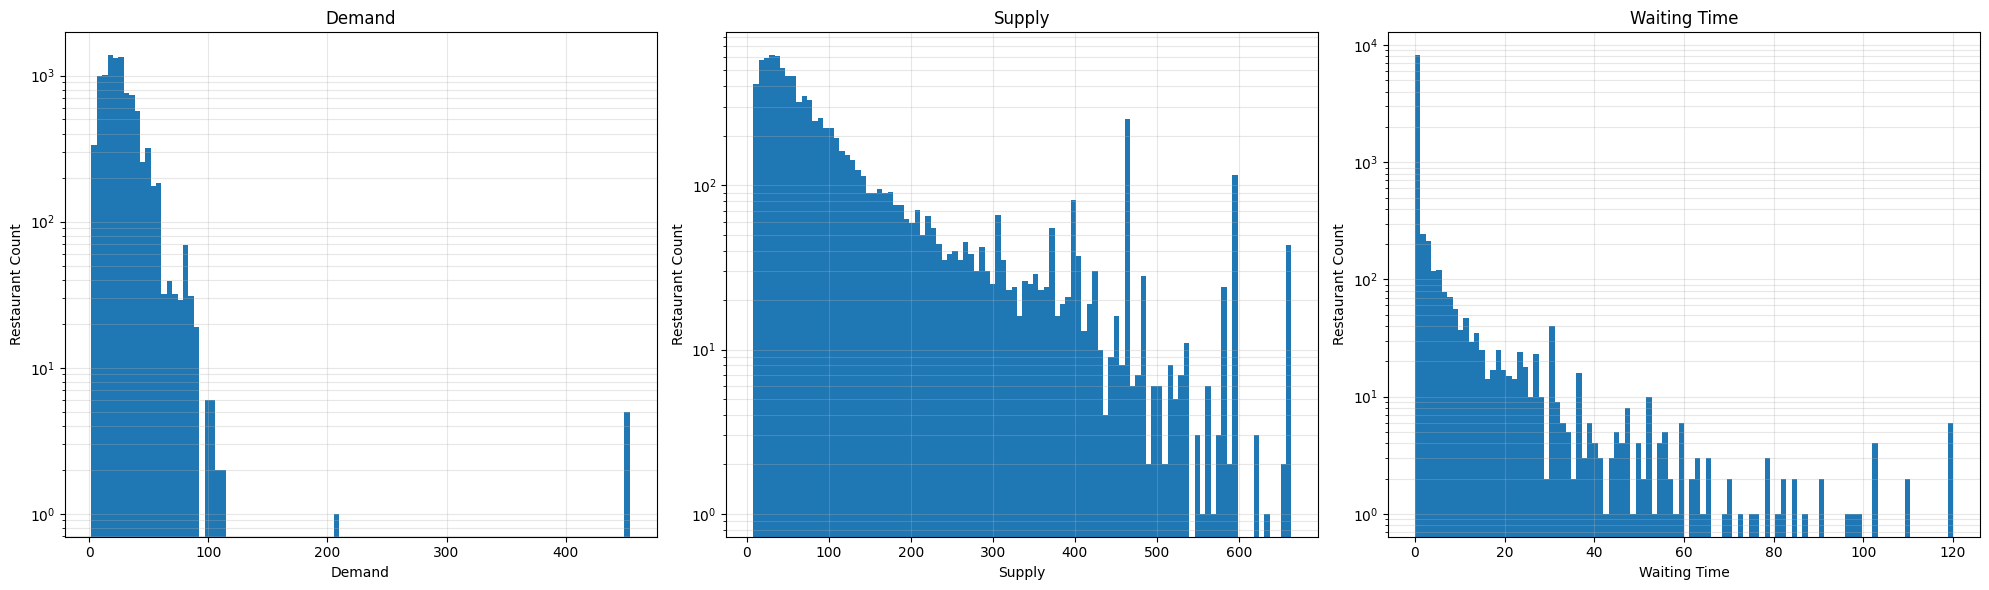

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

df = pd.read_csv("restaurant_wait_now.csv")

# ------------------------
# Variables
# ------------------------

demand = pd.to_numeric(
    df["effective_demand"],
    errors="coerce"
).dropna()

supply = pd.to_numeric(
    df["effective_supply_index"],
    errors="coerce"
).dropna()

wait = pd.to_numeric(
    df["estimated_wait_minutes"],
    errors="coerce"
).dropna()

# ------------------------
# Plot
# ------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20,6)
)

plots = [
    ("Demand", demand),
    ("Supply", supply),
    ("Waiting Time", wait)
]

for ax, (title, series) in zip(axes, plots):

    ax.hist(
        series,
        bins=100
    )

    # only y-axis log scale
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(
        LogLocator(base=10)
    )

    ax.set_title(title)

    ax.set_xlabel(title)
    ax.set_ylabel("Restaurant Count")

    ax.grid(
        alpha=0.3,
        which="both"
    )

plt.tight_layout()
plt.show()

In [24]:
for name, series in plots:

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(series.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ))


Demand
count    9635.000000
mean       26.383469
std        18.172900
min         1.723295
25%        15.660978
50%        23.431257
75%        33.423203
90%        46.267333
95%        54.961278
99%        79.271729
max       453.899025
Name: effective_demand, dtype: float64

Supply
count    9635.000000
mean      125.862882
std       136.712064
min         7.600000
25%        36.132480
50%        71.280000
75%       154.898120
90%       345.600000
95%       460.800000
99%       597.600000
max       664.000000
Name: effective_supply_index, dtype: float64

Waiting Time
count    9635.000000
mean        2.076096
std         8.428846
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
90%         3.863653
95%        11.644996
99%        42.996773
max       120.000000
Name: estimated_wait_minutes, dtype: float64


In [25]:
df["utilization"] = (
    df["effective_demand"]
    /
    df["effective_supply_index"]
)
df["utilization"].describe(
    percentiles=[
        .25,
        .5,
        .75,
        .9,
        .95,
        .99
    ]
)

count    9635.000000
mean        0.554737
std         0.723425
min         0.004519
25%         0.124636
50%         0.295435
75%         0.697335
90%         1.330475
95%         1.906860
99%         3.444161
max        13.432144
Name: utilization, dtype: float64